In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
df_freq = pd.read_csv('freMTPL2freq.csv')
df_sev = pd.read_csv('freMTPL2sev.csv')

print("df-freq:", df_freq.shape)
print("df-sev:", df_sev.shape)

display(df_freq.head())
display(df_sev.head())
display(df_freq.tail())
display(df_sev.tail())

print("df_freq-cols:", df_freq.columns.tolist())
print("df_sev-cols:", df_sev.columns.tolist())

df-freq: (677991, 12)
df-sev: (26444, 2)


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,0,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,0,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,0,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,0,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
677986,6114326.0,0,0.00274,4,0,54,50,B12,Regular,E,3317,Provence-Alpes-Cotes-D'Azur
677987,6114327.0,0,0.00274,4,0,41,95,B12,Regular,E,9850,Ile-de-France
677988,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes
677989,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne
677990,6114330.0,0,0.00274,7,6,29,54,B12,Diesel,B,65,Aquitaine


,IDpol,ClaimAmount
26439,3254353,1200.00
26440,3254353,1800.00
26441,3254353,1000.00
26442,2222064,767.55
26443,2254065,1500.00


df_freq-cols: ['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region']
df_sev-cols: ['IDpol', 'ClaimAmount']


In [4]:
df_freq.info()
print("---------")
df_sev.info()

df_freq["IDpol"] = df_freq["IDpol"].astype("int64")

print(df_freq.dtypes)
print(df_sev.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677991 entries, 0 to 677990
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       677991 non-null  float64
 1   ClaimNb     677991 non-null  int64  
 2   Exposure    677991 non-null  float64
 3   VehPower    677991 non-null  int64  
 4   VehAge      677991 non-null  int64  
 5   DrivAge     677991 non-null  int64  
 6   BonusMalus  677991 non-null  int64  
 7   VehBrand    677991 non-null  object 
 8   VehGas      677991 non-null  object 
 9   Area        677991 non-null  object 
 10  Density     677991 non-null  int64  
 11  Region      677991 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB
---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26444 entries, 0 to 26443
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26444 non-null  in

In [66]:
missing_count_df_freq = df_freq.isnull().sum()
missing_count_df_sev = df_sev.isnull().sum()


print(f"missing_count_df_freq:\n{missing_count_df_freq}")
print(f"missing_count_df_sev:\n{missing_count_df_sev}")

missing_percent_df_freq = (missing_count_df_freq.isnull().sum() / len(df_freq)) * 100
missing_percent_df_sev = (missing_count_df_sev.isnull().sum() / len(df_sev)) * 100

print(f"missing_percent_df_freq: {missing_percent_df_freq}\nmissing_percent_df_sev: {missing_percent_df_sev}")

print("Duplicate rows_df_freq:", df_freq.duplicated().sum())
print("Duplicate rows_df_sev:", df_sev.duplicated().sum())

missing_count_df_freq:
IDpol         0
ClaimNb       0
Exposure      0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Area          0
Density       0
Region        0
dtype: int64
missing_count_df_sev:
IDpol          0
ClaimAmount    0
dtype: int64
missing_percent_df_freq: 0.0
missing_percent_df_sev: 0.0
Duplicate rows_df_freq: 0
Duplicate rows_df_sev: 235


In [5]:
# مدیریت 235 تا ردیف های تکراری

# duplicates_all = df_sev[df_sev.duplicated(keep=False)]
# duplicates_all = duplicates_all.sort_values(["IDpol", "ClaimAmount"])
# duplicates_all

before = len(df_sev)
df_sev = df_sev.drop_duplicates()
after = len(df_sev)

print(f"Rows before: {before}")
print(f"Rows after : {after}")
print(f"Removed    : {before - after}")

Rows before: 26444
Rows after : 26209
Removed    : 235


In [51]:
# آمار خلاصه (میانگین، انحراف معیار، چارک‌ها، حداقل و حداکثر)
display(df_freq.describe().T)
display(df_sev.describe().T)

# بررسی تعداد مقادیر منحصر‌به‌فرد در متغیرهای عددی
print(df_freq.select_dtypes(include=[np.number]).nunique())
print("-------")
print(df_sev.select_dtypes(include=[np.number]).nunique())

,count,mean,std,min,25%,50%,75%,max
IDpol,677991.0,2.621886e+06,1.641776e+06,1.000000,1157964.50,2272157.00,4046271.00,6114330.00
ClaimNb,677991.0,3.900347e-02,2.071688e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,677991.0,5.287428e-01,3.644406e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,677991.0,6.454649e+00,2.050914e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,677991.0,7.044244e+00,5.666226e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,677991.0,4.549909e+01,1.413745e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,677991.0,5.976156e+01,1.563671e+01,50.000000,50.00,50.00,64.00,230.00
Density,677991.0,1.792407e+03,3.958574e+03,1.000000,92.00,393.00,1658.00,27000.00


,count,mean,std,min,25%,50%,75%,max
IDpol,26444.0,2.280004e+06,1.583004e+06,139.0,1.086381e+06,2133756.5,3183952.750,6113971.00
ClaimAmount,26444.0,2.265513e+03,2.937103e+04,1.0,6.859925e+02,1172.0,1212.385,4075400.56


IDpol         677991
ClaimNb           11
Exposure         181
VehPower          12
VehAge            78
DrivAge           83
BonusMalus       115
Density         1607
dtype: int64
-------
IDpol          24944
ClaimAmount    12255
dtype: int64


In [69]:
# انتخاب ستون‌های کلاسی
cat_cols_df_freq = df_freq.select_dtypes(include=['object', 'category']).columns

# بررسی تعداد و تنوع مقادیر در هر ستون متنی
for col in cat_cols_df_freq:
    print(f"=== Column: {col} ===")
    print(f"Unique categories count: {df_freq[col].nunique()}")
    print(df_freq[col].value_counts(dropna=False).head(10)) # ۱۰ کلاس پرتکرار
    print("-" * 30)

=== Column: VehBrand ===
Unique categories count: 11
VehBrand
B12    166022
B1     162730
B2     159854
B3      53393
B5      34752
B6      28545
B4      25179
B10     17707
B11     13585
B13     12177
Name: count, dtype: int64
------------------------------
=== Column: VehGas ===
Unique categories count: 2
VehGas
Regular    345863
Diesel     332128
Name: count, dtype: int64
------------------------------
=== Column: Area ===
Unique categories count: 6
Area
C    191874
D    151592
E    137163
A    103952
B     75457
F     17953
Name: count, dtype: int64
------------------------------
=== Column: Region ===
Unique categories count: 22
Region
Centre                         160595
Rhone-Alpes                     84748
Provence-Alpes-Cotes-D'Azur     79315
Ile-de-France                   69789
Bretagne                        42120
Pays-de-la-Loire                38747
Languedoc-Roussillon            35805
Aquitaine                       31329
Nord-Pas-de-Calais              27284
Poitou-Ch

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
IDpol,1.000000,-0.039205,-0.160157,0.048600,-0.156929,0.063709,-0.005595,0.070779
ClaimNb,-0.039205,1.000000,0.084230,0.000897,0.010328,-0.005028,0.065854,0.010601
Exposure,-0.160157,0.084230,1.000000,-0.045249,0.151563,0.171878,-0.183022,-0.071084
VehPower,0.048600,0.000897,-0.045249,1.000000,-0.006011,0.030111,-0.075900,0.042910
VehAge,-0.156929,0.010328,0.151563,-0.006011,1.000000,-0.059210,0.079918,-0.090422
DrivAge,0.063709,-0.005028,0.171878,0.030111,-0.059210,1.000000,-0.479963,-0.004719
BonusMalus,-0.005595,0.065854,-0.183022,-0.075900,0.079918,-0.479963,1.000000,0.077725
Density,0.070779,0.010601,-0.071084,0.042910,-0.090422,-0.004719,0.077725,1.000000


,IDpol,ClaimAmount
IDpol,1.000000,-0.003871
ClaimAmount,-0.003871,1.000000


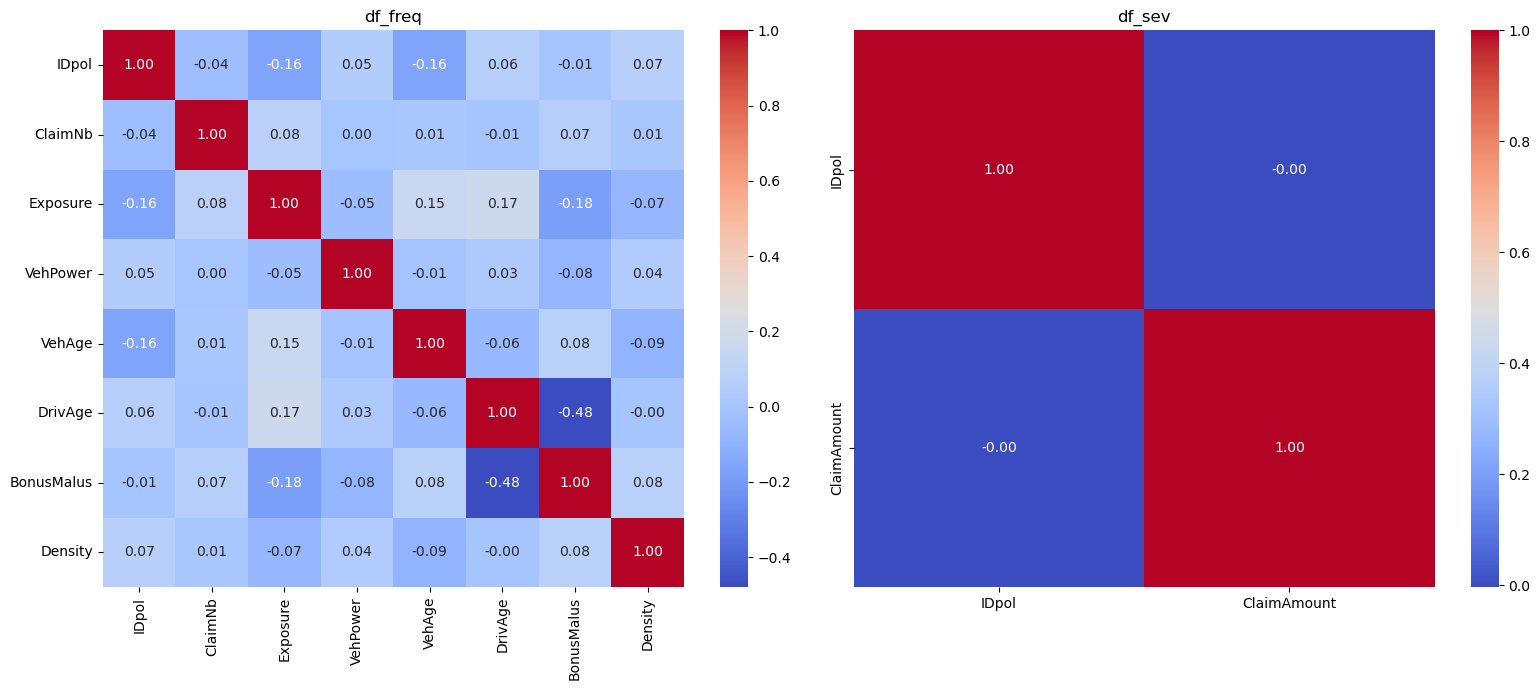

In [6]:
# ماتریس همبستگی بین متغیرهای عددی
numeric_df_freq = df_freq.select_dtypes(include=[np.number])
numeric_df_sev = df_sev.select_dtypes(include=[np.number])

correlation_matrix_df_freq = numeric_df_freq.corr()
correlation_matrix_df_sev = numeric_df_sev.corr()

display(correlation_matrix_df_freq)
display(correlation_matrix_df_sev)

# رسم Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(
    correlation_matrix_df_freq,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0]
)
axes[0].set_title("df_freq")

sns.heatmap(
    correlation_matrix_df_sev,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1]
)
axes[1].set_title("df_sev")

plt.tight_layout()
plt.show()

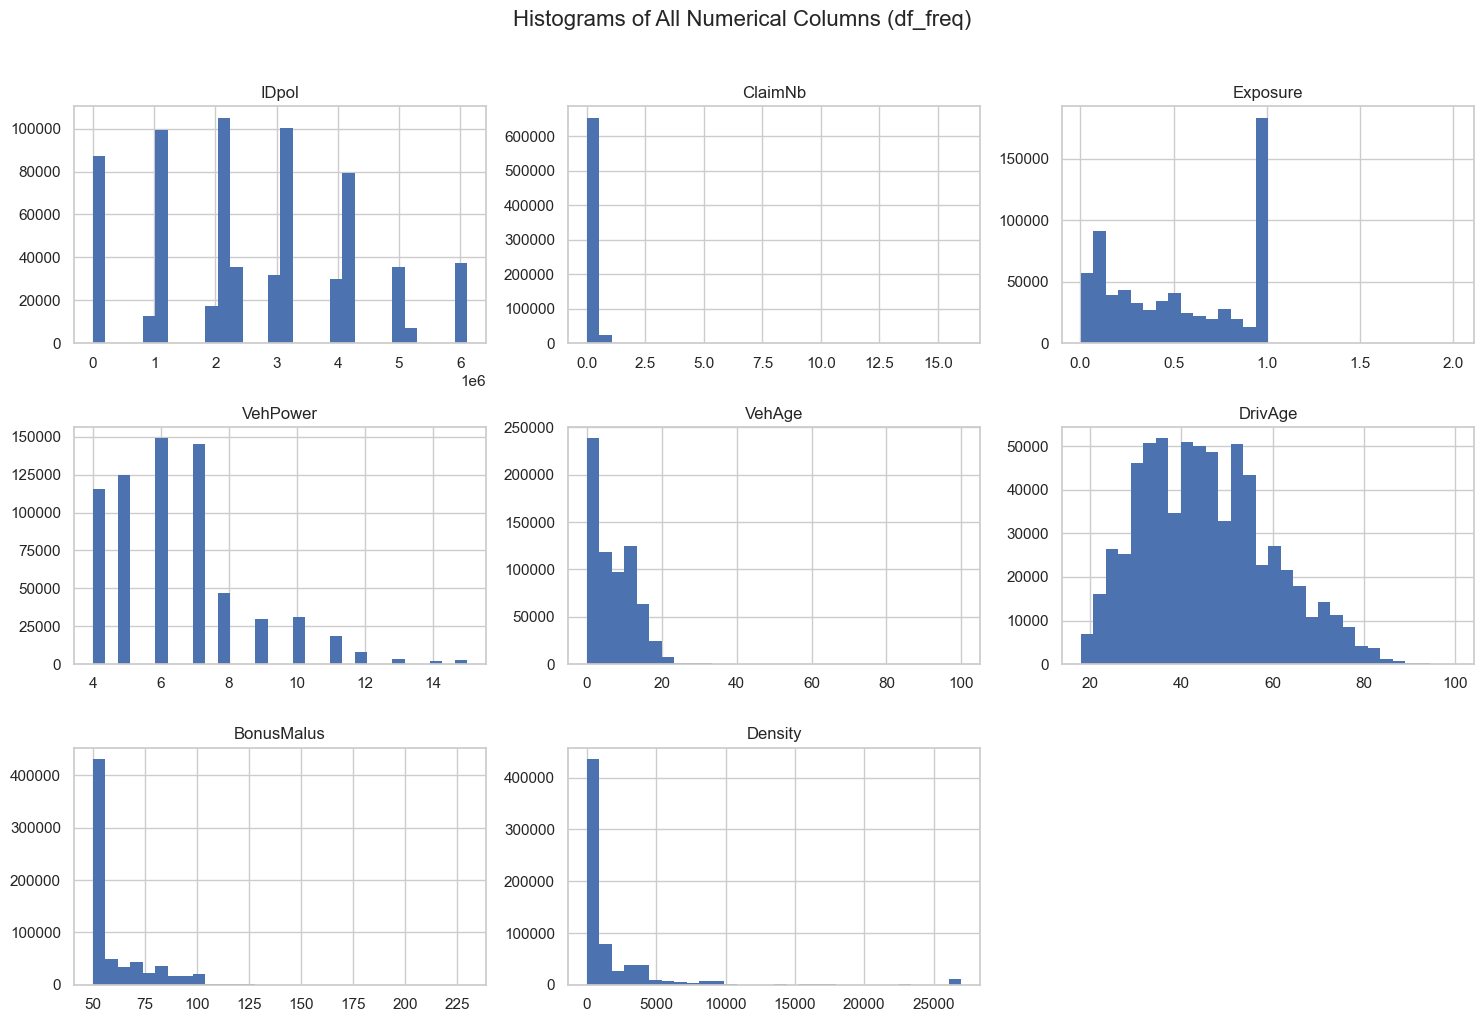

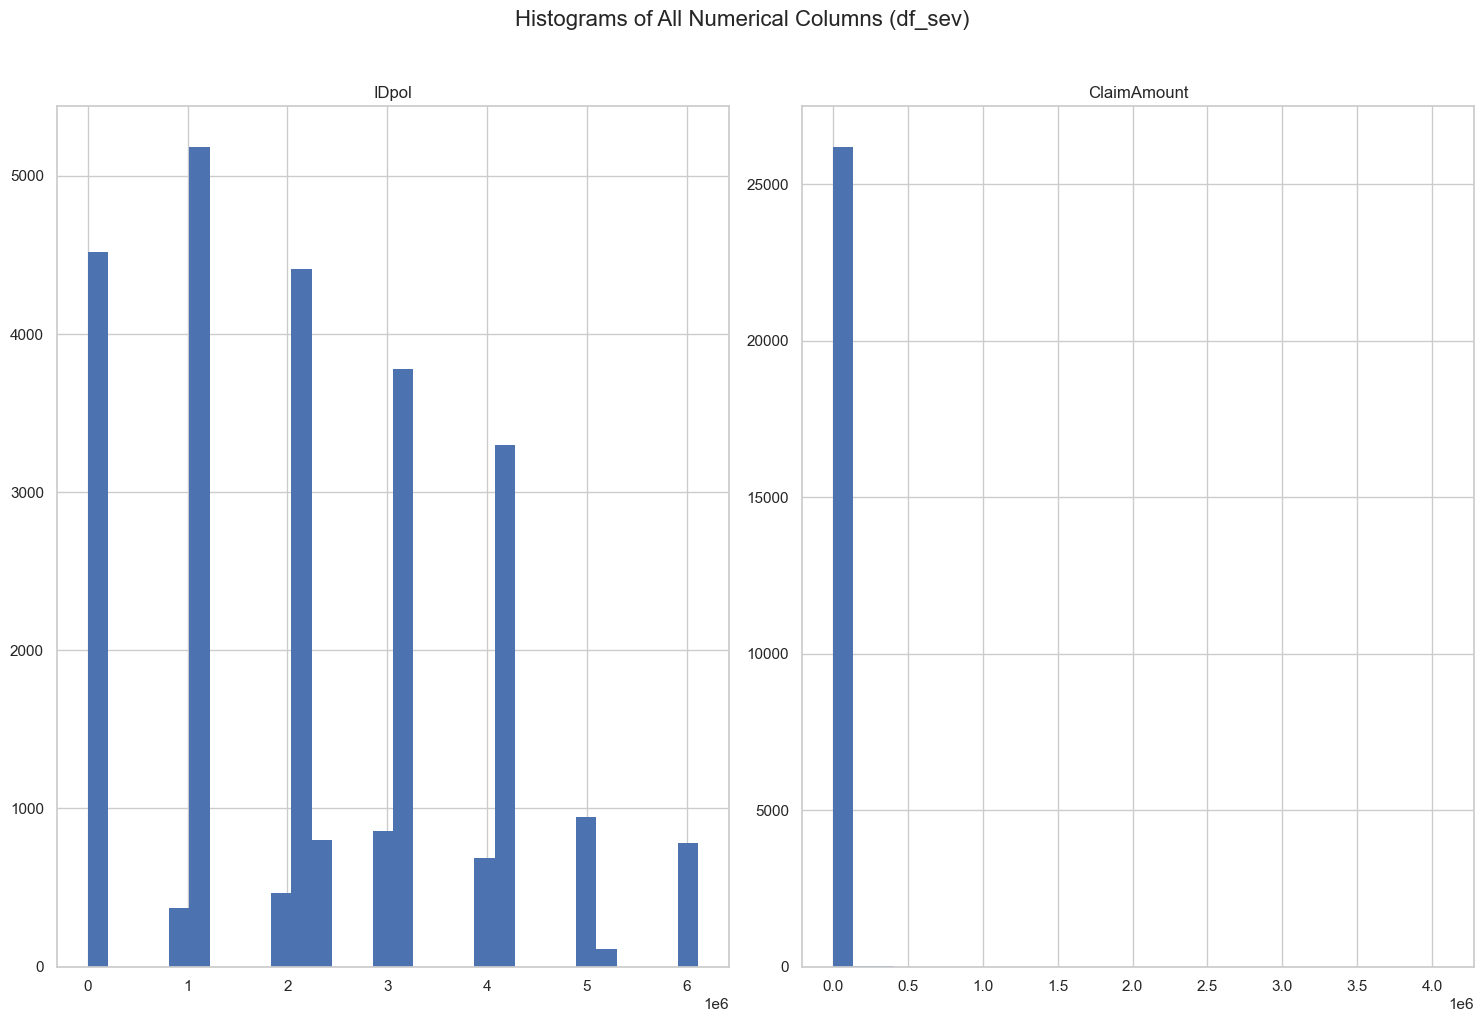

In [8]:
sns.set_theme(style="whitegrid")

# ۱. رسم هیستوگرام تمام ستون‌های df_freq
df_freq.hist(figsize=(15, 10), bins=30, edgecolor='none', grid=True)
plt.suptitle('Histograms of All Numerical Columns (df_freq)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()  

# ۲. رسم هیستوگرام تمام ستون‌های df_sev
df_sev.hist(figsize=(15, 10), bins=30, edgecolor='none', grid=True)
plt.suptitle('Histograms of All Numerical Columns (df_sev)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()  

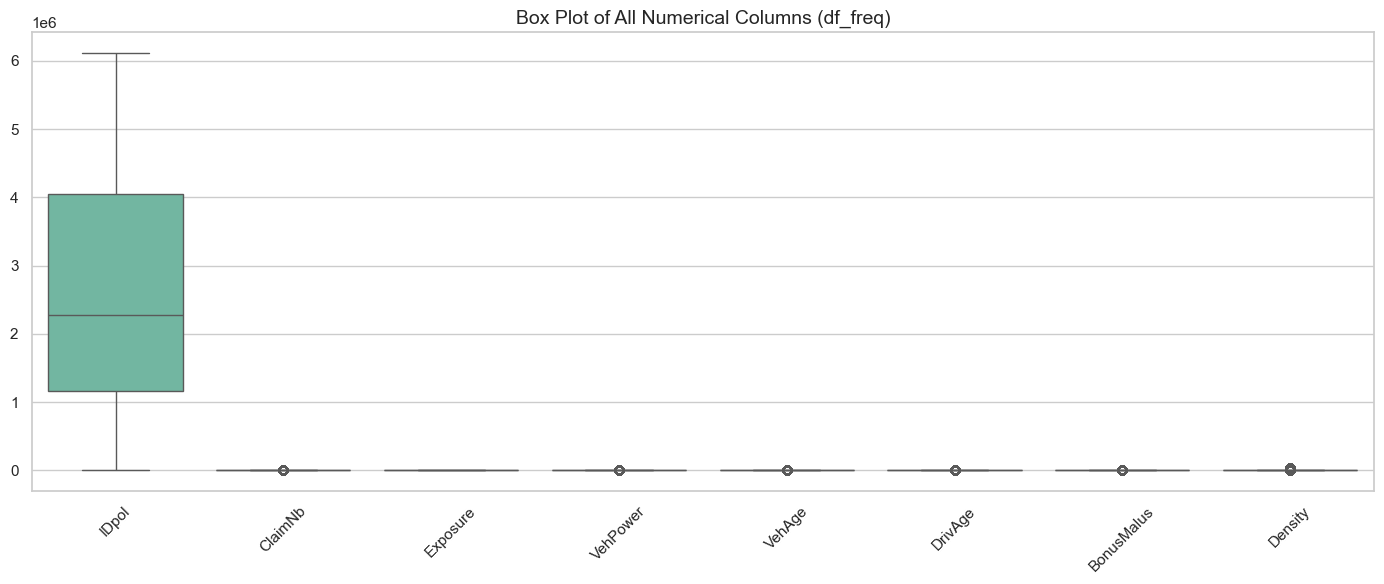

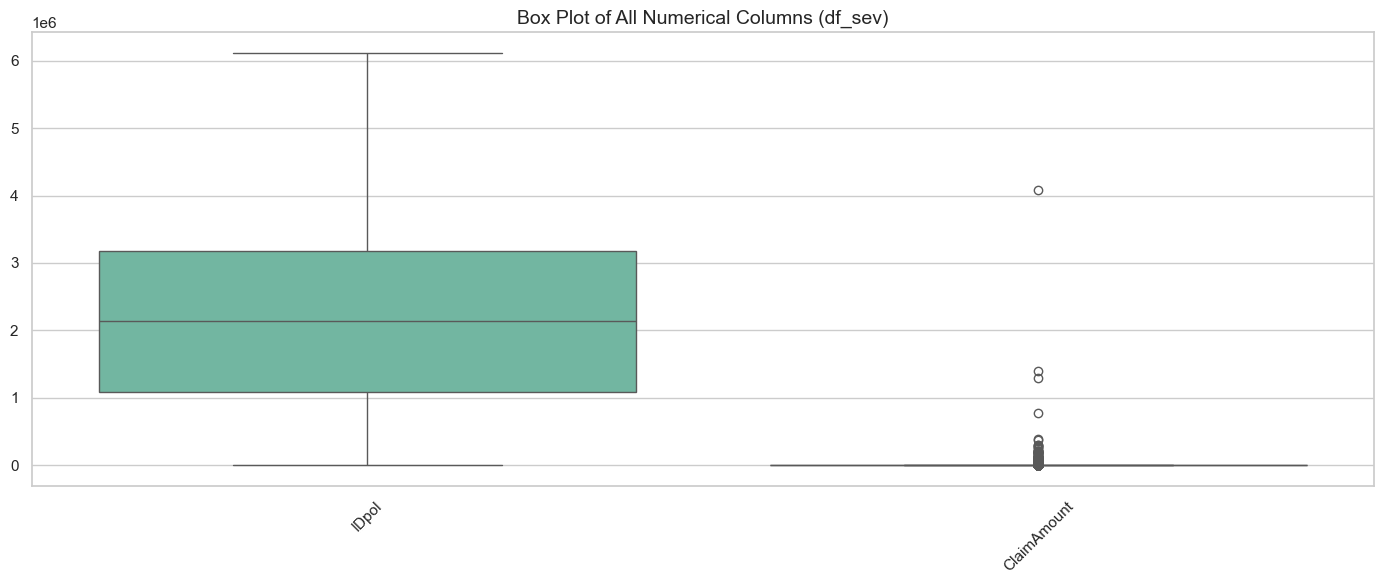

In [9]:
# برای df_freq
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_freq.select_dtypes(include=['number']), palette='Set2')
plt.title('Box Plot of All Numerical Columns (df_freq)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# برای df_sev
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_sev.select_dtypes(include=['number']), palette='Set2')
plt.title('Box Plot of All Numerical Columns (df_sev)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

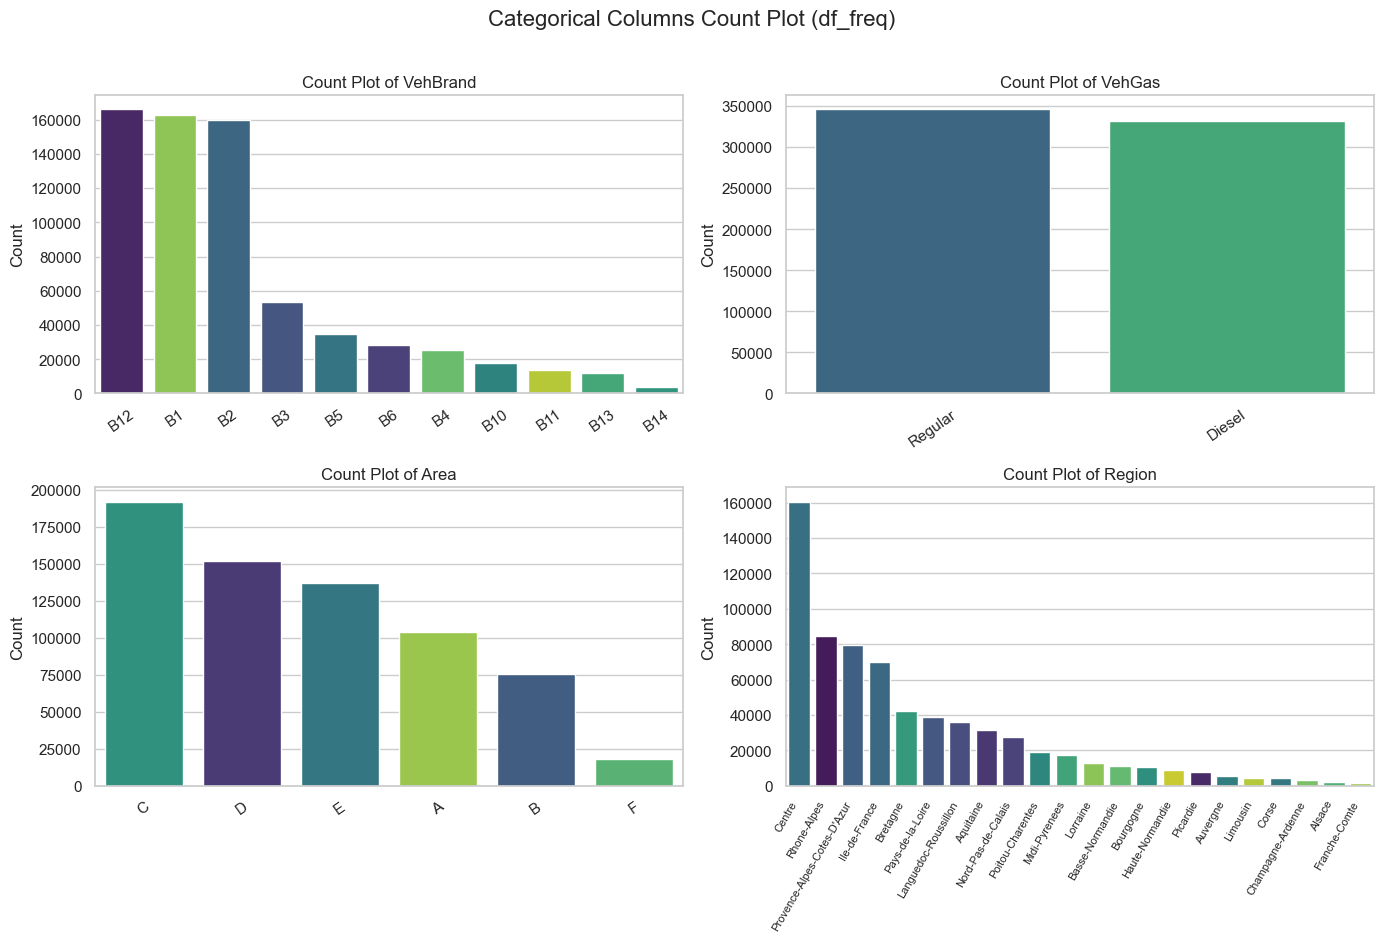

هیچ ستون متنی در df_sev وجود ندارد.


In [10]:
def plot_all_categorical(df, df_name):
    # انتخاب ستون‌های متنی
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    if not cat_cols:
        print(f"هیچ ستون متنی در {df_name} وجود ندارد.")
        return

    ncols = 2
    nrows = math.ceil(len(cat_cols) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.8 * nrows))

    if len(cat_cols) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            x=col,
            order=order,
            hue=col,
            palette="viridis",
            legend=False,
            ax=axes[i]
        )

        axes[i].set_title(f"Count Plot of {col}", fontsize=12)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")

        if col == "Region":
            axes[i].tick_params(axis="x", rotation=60)
            plt.setp(axes[i].get_xticklabels(), ha="right", fontsize=8)
        else:
            axes[i].tick_params(axis="x", rotation=35)

    # حذف محورهای خالی
    for j in range(len(cat_cols), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Categorical Columns Count Plot ({df_name})", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# اجرا
plot_all_categorical(df_freq, "df_freq")
plot_all_categorical(df_sev, "df_sev")

In [57]:
df_sev.to_csv("df_sev_clean.csv", index=False)